In [1]:
import yfinance as yf

usd = yf.download(
    "IDR=X",
    start="2020-01-01",
    end="2026-06-11",
    interval="1d",
    auto_adjust=True
)

usd.to_csv("usd.csv")
usd.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,IDR=X,IDR=X,IDR=X,IDR=X,IDR=X
Date,,,,,
2020-01-01,13690.372070,13876.000000,13681.833984,13862.000000,0
2020-01-02,13689.231445,13906.000000,13688.203125,13847.000000,0
2020-01-03,13884.786133,13966.000000,13775.500000,13881.299805,0
2020-01-06,13934.316406,13973.299805,13916.000000,13931.132812,0
2020-01-07,13926.500000,13939.000000,13875.500000,13929.000000,0


In [2]:
from google.colab import files

files.download("usd.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
usd = pd.read_csv("usd.csv")

In [4]:
usd = usd.iloc[2:].copy()

usd = usd[["Price","Close"]]

usd.columns = ["Date","USDIDR"]

usd["Date"] = pd.to_datetime(usd["Date"])

usd["USDIDR"] = pd.to_numeric(usd["USDIDR"])

usd = usd.sort_values("Date")

usd.head()

,Date,USDIDR
2,2020-01-01,13690.372070
3,2020-01-02,13689.231445
4,2020-01-03,13884.786133
5,2020-01-06,13934.316406
6,2020-01-07,13926.500000


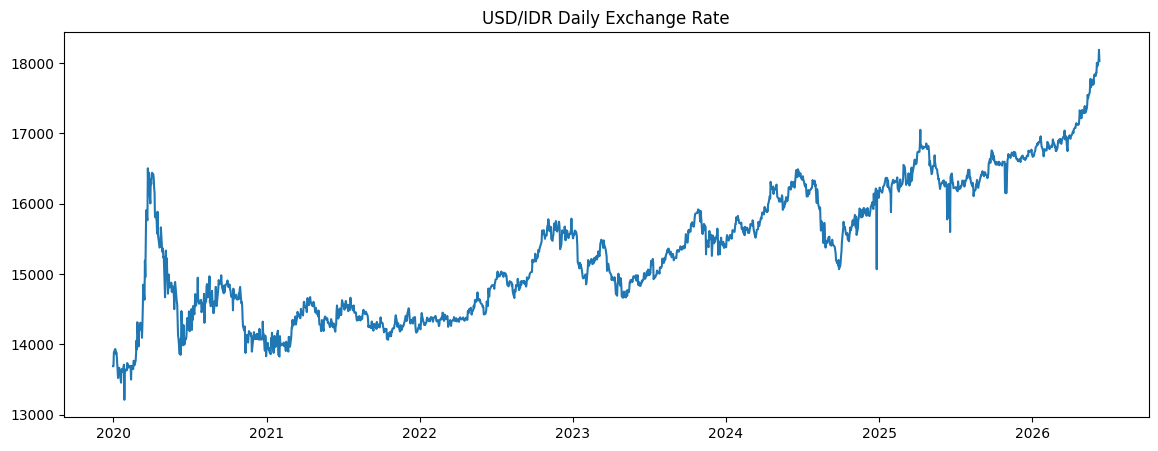

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    usd["Date"],
    usd["USDIDR"]
)

plt.title("USD/IDR Daily Exchange Rate")

plt.show()

In [6]:
usd.tail()

,Date,USDIDR
1673,2026-06-04,18004.199219
1674,2026-06-05,17955.500000
1675,2026-06-08,18029.000000
1676,2026-06-09,18190.300781
1677,2026-06-10,18031.000000


In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    usd["USDIDR"]
)

print(result[1])

0.8443131349584695


In [10]:
train_diff = usd["USDIDR"].diff()

train_diff = train_diff.dropna()

In [11]:
result = adfuller(
    train_diff
)

print(result[1])

2.5293522587795394e-30


In [12]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.8 MB/s eta 0:00:00


In [13]:
from pmdarima import auto_arima

final_model = auto_arima(
    usd["USDIDR"],
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

print(final_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=20277.518, Time=3.81 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20498.188, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20302.313, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=20287.576, Time=0.42 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=20497.121, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=20289.268, Time=1.95 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=20282.451, Time=1.61 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=20283.265, Time=3.79 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=20274.704, Time=3.93 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=20280.719, Time=1.26 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=20275.907, Time=3.63 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=20276.121, Time=3.57 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=20282.231, Time=3.47 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=20274.402, Time=5.19 sec
 ARIMA(4,1,4)(0,0,0

In [14]:
future = final_model.predict(
    n_periods=30
)

In [15]:
import pandas as pd

future_dates = pd.date_range(
    start=usd["Date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

In [16]:
usd.index.dtype
usd.index.max()
usd.sort_index().tail()

,Date,USDIDR
1673,2026-06-04,18004.199219
1674,2026-06-05,17955.500000
1675,2026-06-08,18029.000000
1676,2026-06-09,18190.300781
1677,2026-06-10,18031.000000


In [19]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_USDIDR": future
})

forecast_df.head()

,Date,Forecast_USDIDR
1678,2026-06-11,18092.765513
1679,2026-06-12,18087.916295
1680,2026-06-13,18086.135440
1681,2026-06-14,18109.180041
1682,2026-06-15,18101.464922


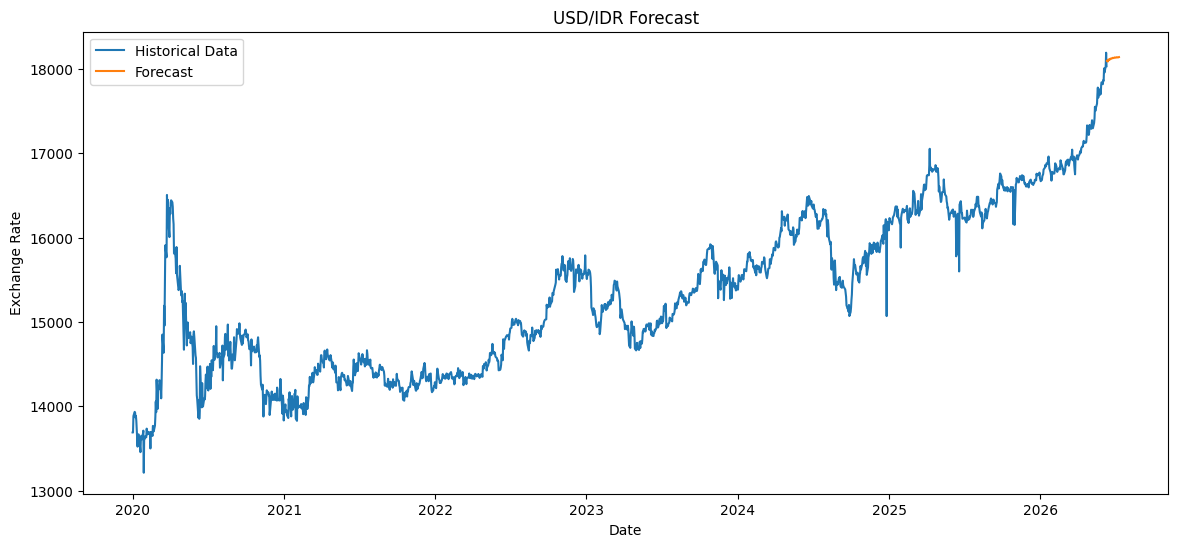

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    usd["Date"],
    usd["USDIDR"],
    label="Historical Data"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast_USDIDR"],
    label="Forecast"
)

plt.title("USD/IDR Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()

plt.show()

In [21]:
forecast_df

,Date,Forecast_USDIDR
1678,2026-06-11,18092.765513
1679,2026-06-12,18087.916295
1680,2026-06-13,18086.135440
1681,2026-06-14,18109.180041
1682,2026-06-15,18101.464922
1683,2026-06-16,18107.437052
1684,2026-06-17,18105.301157
1685,2026-06-18,18112.384097
1686,2026-06-19,18118.707971
1687,2026-06-20,18120.776240


In [23]:
!pip install plotly -q

In [28]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

actual = usd[['Date','USDIDR']].copy()
actual['Date'] = pd.to_datetime(actual['Date'])
actual['Type'] = 'Actual'

forecast = forecast_df.copy()
forecast['Date'] = pd.to_datetime(forecast['Date'])
forecast['Type'] = 'Forecast'
forecast.rename(columns={'Forecast_USDIDR':'USDIDR'}, inplace=True) # Corrected line

dashboard_data = pd.concat([actual, forecast])
dashboard_data = dashboard_data.sort_values('Date')

In [29]:
last_actual = actual['USDIDR'].iloc[-1]

forecast_end = forecast['USDIDR'].iloc[-1]

change_pct = ((forecast_end - last_actual)
              / last_actual) * 100

trend = "Bullish ↗" if change_pct > 0 else "Bearish ↘"

print(f"Last Rate       : {last_actual:,.2f}")
print(f"Forecast End    : {forecast_end:,.2f}")
print(f"Expected Change : {change_pct:.2f}%")
print(f"Trend           : {trend}")

Last Rate       : 18,031.00
Forecast End    : 18,138.47
Expected Change : 0.60%
Trend           : Bullish ↗


In [31]:
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.75,0.25],
    vertical_spacing=0.12,
    subplot_titles=(
        "USD/IDR Actual vs Forecast",
        "30-Day Forecast"
    ),
    specs=[[{}], [{'type': 'table'}]] # Added specs to define subplot types
)

#Actual

fig.add_trace(
    go.Scatter(
        x=actual['Date'],
        y=actual['USDIDR'],
        mode='lines',
        name='Actual'
    ),
    row=1,
    col=1
)

#Forecast

fig.add_trace(
    go.Scatter(
        x=forecast['Date'],
        y=forecast['USDIDR'],
        mode='lines',
        name='Forecast'
    ),
    row=1,
    col=1
)

#Forecast table

fig.add_trace(
    go.Table(
        header=dict(
            values=["Date","Forecast"]
        ),
        cells=dict(
            values=[
                forecast['Date'].dt.strftime("%d-%b-%Y"),
                round(forecast['USDIDR'],2)
            ]
        )
    ),
    row=2,
    col=1
)

fig.update_layout(
    title={
        "text":
        f"""
        USD/IDR Forecast Dashboard<br>
        Last Rate: {last_actual:,.2f}
        | Forecast End: {forecast_end:,.2f}
        | Change: {change_pct:.2f}%
        | {trend}
        """,
        "x":0.5
    },
    height=900,
    template="plotly_white"
)

fig.show()

In [37]:
# Convert Timestamp to milliseconds since epoch for x-coordinate
line_x = forecast['Date'].iloc[0].timestamp() * 1000

# Add the vertical line as a shape
fig.add_shape(
    type="line",
    x0=line_x,
    x1=line_x,
    y0=0,
    y1=1,
    yref="y1",  # Reference y-axis of the first subplot
    line=dict(dash="dash"),
    row=1, col=1 # Specify the subplot for the vertical line
)

# Add the annotation separately
fig.add_annotation(
    text="Forecast Start",
    x=line_x,
    y=1, # Position at the top of the y-axis (normalized 0-1)
    yref="y1", # Reference y-axis of the first subplot
    xref="x1", # Reference x-axis of the first subplot
    showarrow=False,
    row=1, col=1 # Specify the subplot for the annotation
)

In [41]:
fig.add_vline(
    x=forecast['Date'].iloc[0].timestamp() * 1000, # Convert Timestamp to milliseconds since epoch
    line_dash="dash",
    annotation_text="Forecast Start"
)

In [42]:
fig.write_html(
    "USDIDR_Forecast_Dashboard.html"
)

print("Dashboard berhasil disimpan.")

Dashboard berhasil disimpan.


In [43]:
from google.colab import files

files.download(
    "USDIDR_Forecast_Dashboard.html"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>